<a href="https://colab.research.google.com/github/Ziyadk147/23-ai-05-CV-OEL/blob/main/23_ai_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

23-AI-05 2. Handwritten Character & Digit Classifier

In [22]:
import kagglehub
import os
import numpy as np
import pandas as pd
from keras import Sequential
from keras.models import Model
from keras.layers import Dense , Flatten , Conv2D , MaxPooling2D, Dropout , BatchNormalization , GlobalAveragePooling2D
from keras.applications import MobileNetV2
from keras.optimizers import Adam
import cv2
import matplotlib.pyplot as plt



In [4]:
# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emnist' dataset.
Path to dataset files: /kaggle/input/emnist


In [5]:
data = pd.read_csv("/content/sample_data/mnist_train_small.csv", header=None).values

y = data[:, 0]
X = data[:, 1:].astype("float32") / 255.0

X = X.reshape(-1, 28, 28)
X_cnn = X.reshape(-1, 28, 28, 1)

Manually implement Sobel and Laplacian kernels using NumPy; apply to sample
characters and compare stroke edge outputs against cv2 built-ins


In [6]:
def convolve2d(image, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(image, pad, mode='constant')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k, j:j+k]
            out[i, j] = np.sum(region * kernel)

    return out

In [7]:
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
lap_kernel = np.array([[0,1,0],[1,-4,1],[0,1,0]])

img = X[0]

gx = convolve2d(img, sobel_x)
gy = convolve2d(img, sobel_y)
sobel_manual = np.sqrt(gx**2 + gy**2)

laplacian_manual = convolve2d(img, lap_kernel)

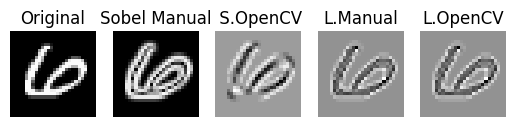

In [8]:
sobel_cv = cv2.Sobel(img, cv2.CV_64F, 1, 1)
laplacian_cv = cv2.Laplacian(img, cv2.CV_32F)

titles = ["Original", "Sobel Manual", " S.OpenCV", "L.Manual", "L.OpenCV"]
images = [img, sobel_manual, sobel_cv, laplacian_manual, laplacian_cv]

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


Train a fully-connected NN; then add a hidden layer and compare; record accuracy and
loss curves for both.


In [9]:
hiddenModel = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])
normal = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
for model in [hiddenModel , normal]:
  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=['accuracy']
  )

model1_result = hiddenModel.fit(X , y , epochs=10, validation_split=0.2)
model2_result = normal.fit(X , y , epochs=10, validation_split=0.2)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8127 - loss: 0.7549 - val_accuracy: 0.8913 - val_loss: 0.4522
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8978 - loss: 0.3902 - val_accuracy: 0.9015 - val_loss: 0.3722
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.3351 - val_accuracy: 0.9085 - val_loss: 0.3374
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9141 - loss: 0.3083 - val_accuracy: 0.9120 - val_loss: 0.3240
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9188 - loss: 0.2921 - val_accuracy: 0.9120 - val_loss: 0.3142
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9215 - loss: 0.2793 - val_accuracy: 0.9133 - val_loss: 0.3090
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9248 - loss: 0.2705 - val_accuracy: 0.9137 - val_loss: 0.3036
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9257 - loss: 0.2636 - val_accuracy: 0.

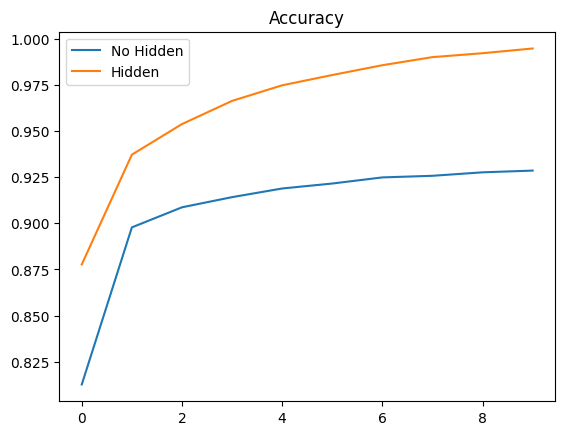

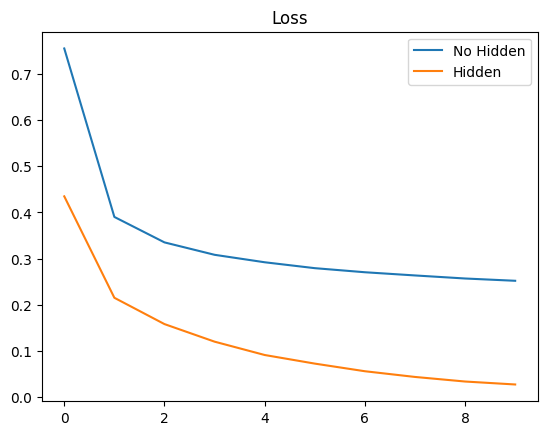

In [11]:
plt.plot(model1_result.history['accuracy'], label='No Hidden')
plt.plot(model2_result.history['accuracy'], label='Hidden')
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(model1_result.history['loss'], label='No Hidden')
plt.plot(model2_result.history['loss'], label='Hidden')
plt.legend(); plt.title("Loss"); plt.show()

Design a CNN from scratch (Conv2D → MaxPool2D blocks → Dense head); apply
dropout and batch normalization; plot overfitting behavior across 20 epochs.

In [12]:

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn_result = cnn.fit(X_cnn, y, epochs=20, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8771 - loss: 0.4002 - val_accuracy: 0.9390 - val_loss: 0.1942
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9511 - loss: 0.1605 - val_accuracy: 0.9770 - val_loss: 0.0697
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9664 - loss: 0.1122 - val_accuracy: 0.9783 - val_loss: 0.0717
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9714 - loss: 0.0918 - val_accuracy: 0.9827 - val_loss: 0.0618
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0760 - val_accuracy: 0.9833 - val_loss: 0.0563
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9804 - loss: 0.0639 - val_accuracy: 0.9868 - val_loss: 0.0482
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9835 - loss: 0.0495 - val_accuracy: 0.9850 - val_loss: 0.0556
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0497 - val_accuracy: 0.

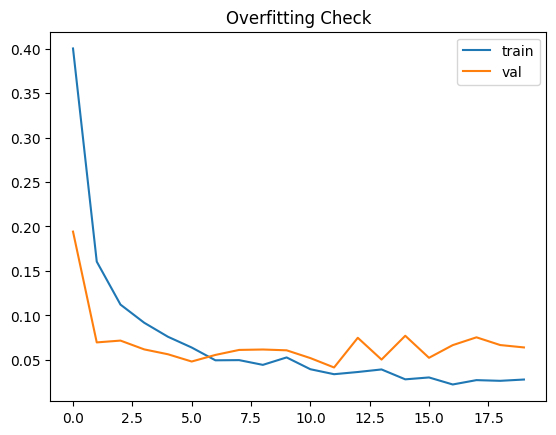

In [13]:
plt.plot(cnn_result.history['loss'], label='train')
plt.plot(cnn_result.history['val_loss'], label='val')
plt.legend();
plt.title("Overfitting Check");
plt.show()

Use MobileNetV2 with a frozen base for transfer learning; fine-tune top 10 layers with
differential learning rates; plot LR vs. epoch curves.


In [14]:
X_resized = np.array([cv2.resize(img, (96,96)) for img in X])
X_resized = X_resized.reshape(-1,96,96,1)
X_rgb = np.repeat(X_resized, 3, axis=-1)

In [15]:
base = MobileNetV2(weights = 'imagenet' , include_top=False , input_shape=(96,96,3)
)
base.trainable = False
model_mobileNet = Sequential(
    [
        base ,
        GlobalAveragePooling2D(),
        Dense(128 , activation="relu"),
        Dense(10 , activation="softmax")
    ]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
base.trainable = False
for layer in base.layers[:-10]:
  layer.trainable = True


In [17]:
model_mobileNet.compile(optimizer=Adam(learning_rate=1e-4),
                        loss = 'sparse_categorical_crossentropy',
                        metrics=['accuracy'])

model_mobilenet_result = model_mobileNet.fit(X_rgb , y , epochs=10 , validation_split=0.2)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.9313 - loss: 0.2219 - val_accuracy: 0.4442 - val_loss: 1.6331
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9904 - loss: 0.0285 - val_accuracy: 0.6898 - val_loss: 1.0347
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.9942 - loss: 0.0157 - val_accuracy: 0.6335 - val_loss: 1.1554
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9964 - loss: 0.0107 - val_accuracy: 0.5900 - val_loss: 1.4166
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.7180 - val_loss: 0.9331
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9959 - loss: 0.0136 - val_accuracy: 0.8070 - val_loss: 0.6946
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9962 - loss: 0.0109 - val_accuracy: 0.9252 - val_loss: 0.2419
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9958 - loss: 0.0149 - 

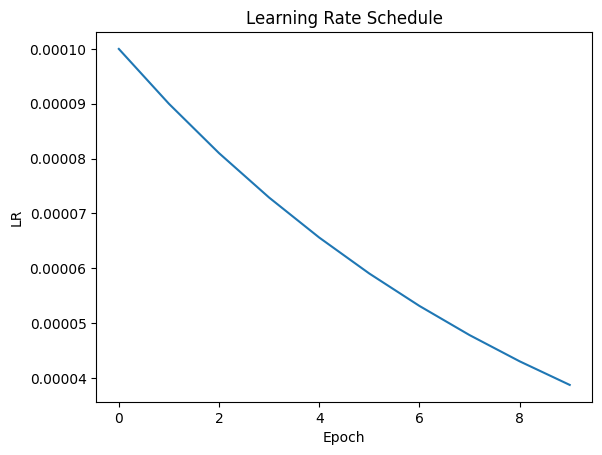

In [18]:
lrs = [1e-4 * (0.9 ** i) for i in range(10)]
plt.plot(lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.show()

plement a mini-VGG (2 VGG-style blocks) and compare it against the scratch CNN
and MobileNetV2; visualize intermediate feature maps from conv layers.


In [21]:
model_vgg = Sequential([
    Conv2D(32,  (3,3) , activation= "relu" ,padding="same", input_shape=(28,28,1)),
    Conv2D(32 , (3,3) , activation="relu",padding="same"),
    MaxPooling2D(),
    Conv2D(64 , (3,3) , activation="relu" , padding="same"),
    Conv2D(64 , (3,3) , activation="relu" , padding="same"),
    MaxPooling2D(),
    Flatten(),
    Dense(128,  activation="relu"),
    Dense(10, activation="softmax")
])
model_vgg.compile(optimizer="adam" ,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
model_vgg_result = model_vgg.fit(X_cnn , y , epochs=10 , validation_split=0.2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9283 - loss: 0.2218 - val_accuracy: 0.9703 - val_loss: 0.0998
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9804 - loss: 0.0620 - val_accuracy: 0.9822 - val_loss: 0.0595
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0.9868 - val_loss: 0.0444
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9896 - loss: 0.0300 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0212 - val_accuracy: 0.9825 - val_loss: 0.0683
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9946 - loss: 0.0178 - val_accuracy: 0.9862 - val_loss: 0.0504
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9953 - loss: 0.0155 - val_accuracy: 0.9818 - val_loss: 0.0675
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9958 - loss: 0.0124 - val_accuracy: 0.9843 - val_

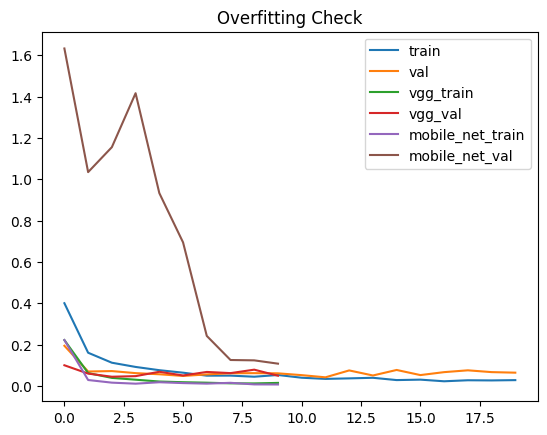

In [27]:
plt.plot(cnn_result.history['loss'], label='train')
plt.plot(cnn_result.history['val_loss'], label='val')

plt.plot(model_vgg_result.history['loss'], label='vgg_train')
plt.plot(model_vgg_result.history['val_loss'], label='vgg_val')


plt.plot(model_mobilenet_result.history['loss'], label='mobile_net_train')
plt.plot(model_mobilenet_result.history['val_loss'], label='mobile_net_val')

plt.legend();
plt.title("Overfitting Check");
plt.show()

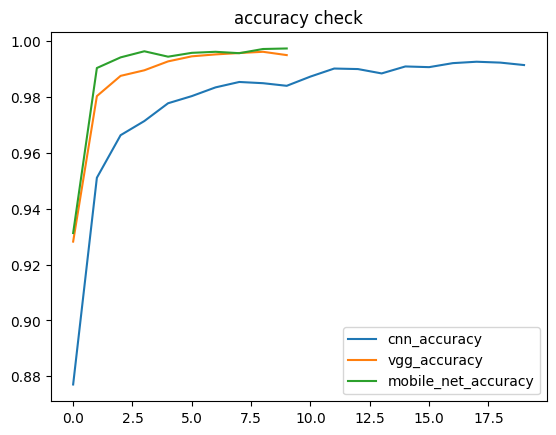

In [30]:
plt.plot(cnn_result.history['accuracy'], label='cnn_accuracy')
plt.plot(model_vgg_result.history['accuracy'], label='vgg_accuracy')
plt.plot(model_mobilenet_result.history['accuracy'], label='mobile_net_accuracy')

plt.legend();
plt.title("accuracy check");
plt.show()